# Benchmark of first and second pass integration tools on all annotated cells

In [1]:
import os
import sys
import glob
from pyhere import here
from pathlib import Path

import anndata
import numpy as np
import pandas as pd
import scanpy as sc
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
import seaborn as sns
import torch
import skmisc
import subprocess
from joblib import parallel_backend
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.backends.backend_pdf import PdfPages
import warnings

import plotly.express as px 
import zstandard as zstd 
import hdf5plugin

import pickle

# My modules / functions
sys.path.append(str(here('scripts/misc')))  
import my_anndata as ma

In [2]:
# Directories
ma.create_directories(dir_path = str(here('data/integrate/second_pass')))
ma.create_directories(dir_path = str(here('data/integrate/second_pass/tmp')))
ma.create_directories(dir_path = str(here('data/integrate/second_pass/embedding')))
ma.create_directories(dir_path = str(here('data/integrate/second_pass/files')))
ma.create_directories(dir_path = str(here('data/integrate/second_pass/plot')))
ma.create_directories(dir_path = str(here('data/integrate/second_pass/objects')))
ma.create_directories(dir_path = str(here('data/integrate/second_pass/models')))

/work/islet_cartography_scrna/data/integrate/second_pass Directory already exists!
/work/islet_cartography_scrna/data/integrate/second_pass/tmp Directory already exists!
/work/islet_cartography_scrna/data/integrate/second_pass/embedding Directory already exists!
/work/islet_cartography_scrna/data/integrate/second_pass/files Directory already exists!
/work/islet_cartography_scrna/data/integrate/second_pass/plot Directory already exists!
/work/islet_cartography_scrna/data/integrate/second_pass/objects Directory already exists!
/work/islet_cartography_scrna/data/integrate/second_pass/models Directory already exists!


In [3]:
# Saving
base_dir = str(here('data/integrate/second_pass/'))
file_dir = os.path.join(base_dir, 'files') 
plot_dir = os.path.join(base_dir, 'plot') 
tmp_dir = os.path.join(base_dir, 'tmp') 
emb_dir = os.path.join(base_dir, 'embedding') 
objects_dir = os.path.join(base_dir, 'objects') 
model_dir = os.path.join(base_dir, 'models')

In [5]:
# hvgs 
hvgs = [1000]

technical_seperate = ['cell_nuclei', 'ic_id_study_overall', 'library_prep', 'ic_id_donor_overall']

celltype = 'study_cell_annotation_harmonized' 

## Load Full adata object

In [171]:
# Load reference adata object
adata_full =sc.read_h5ad('/work/scRNAseq/JM/adata_full_with_latent.h5ad')

## Get embedding names

In [14]:
# Keep embedding names of interest
embedding_keys = [x for x in adata_full.obsm.keys() if not x.endswith('_umap') and (x.endswith('_1000') or x == "X_latent_2")]
embedding_keys

['X_latent_2', 'pca_1000', 'scpoli_1000', 'scvi_1000', 'sysvi_1000']

## Subset data to only contain annotated cells

In [174]:
celltype = "study_cell_annotation_harmonized"

n_before = adata_full.n_obs
adata_sub = adata_full[~adata_full.obs[celltype].isin(["unknown", "excluded"])].copy()
adata_sub.obs[celltype] = adata_sub.obs[celltype].astype("category")
adata_sub.obs[celltype] = adata_sub.obs[celltype].cat.remove_unused_categories()

n_after = adata_sub.n_obs
print(f"Filtered {n_before - n_after} cells (kept {n_after})")

Filtered 323202 cells (kept 266000)


## Benchmark for subset of cells

In [16]:
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        category=FutureWarning,
        message="Argument `use_highly_variable` is deprecated.*"
    )
    
    results = {}
    results_norm = {}
    
    for technical in technical_seperate:

        print(f'Running {technical}')
        
        bm = Benchmarker(
            adata_sub,
            batch_key=technical,
            label_key=celltype,
            bio_conservation_metrics=BioConservation(),
            batch_correction_metrics=BatchCorrection(kbet_per_label = False),
            embedding_obsm_keys=embedding_keys,
            n_jobs=100,
        )
    
        bm.benchmark()

        # save results
        results[technical] = bm.get_results(min_max_scale=False)
        results_norm[technical] = bm.get_results(min_max_scale=True)

        bm.get_results(min_max_scale=False).to_csv(os.path.join(file_dir, f'benchmark_celltype_sub_results_{technical}.csv'), index=True)
        bm.get_results(min_max_scale=True).to_csv(os.path.join(file_dir, f'benchmark_celltype_sub_norm_results_{technical}.csv'), index=True)
    
    
        print(f"[OK] Finished benchmark for {technical}")

Running cell_nuclei


Metrics:  60%|██████    | 6/10 [02:15<00:57, 14.28s/it, Batch correction: graph_connectivity]/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)

Embeddings:  20%|██        | 1/5 [02:17<09:08, 137.24s/it]tch correction: pcr_comparison]
                                                                                         
Metrics:  60%|██████    | 6/10 [02:03<00:53, 13.29s/it, Batch correction: graph_connectivity]/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)

Embeddings:  40%|████      | 2

[OK] Finished benchmark for cell_nuclei
Running ic_id_study_overall


Metrics:  60%|██████    | 6/10 [02:26<01:09, 17.50s/it, Batch correction: graph_connectivity]/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)

Embeddings:  20%|██        | 1/5 [02:28<09:52, 148.03s/it]tch correction: pcr_comparison]
                                                                                         
Metrics:  60%|██████    | 6/10 [02:13<01:03, 15.82s/it, Batch correction: graph_connectivity]/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)

Embeddings:  40%|████      | 2

[OK] Finished benchmark for ic_id_study_overall
Running library_prep


Metrics:  60%|██████    | 6/10 [02:24<01:07, 16.98s/it, Batch correction: graph_connectivity]/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)

Embeddings:  20%|██        | 1/5 [02:25<09:42, 145.67s/it]tch correction: pcr_comparison]
                                                                                         
Metrics:  60%|██████    | 6/10 [02:13<01:02, 15.74s/it, Batch correction: graph_connectivity]/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)

Embeddings:  40%|████      | 2

[OK] Finished benchmark for library_prep
Running ic_id_donor_overall


Metrics:  60%|██████    | 6/10 [02:27<01:10, 17.57s/it, Batch correction: graph_connectivity]/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)

Embeddings:  20%|██        | 1/5 [02:31<10:05, 151.31s/it]tch correction: pcr_comparison]
                                                                                         
Metrics:  60%|██████    | 6/10 [02:12<01:02, 15.75s/it, Batch correction: graph_connectivity]/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)

Embeddings:  40%|████      | 2

[OK] Finished benchmark for ic_id_donor_overall


/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/scib_metrics/benchmark/_core.py:299: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Aggregate score' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[_METRIC_TYPE, per_class_score.columns] = _AGGREGATE_SCORE
/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/scib_metrics/benchmark/_core.py:299: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Aggregate score' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[_METRIC_TYPE, per_class_score.columns] = _AGGREGATE_SCORE
/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/scib_metrics/benchmark/_core.py:299: FutureWarning: Set

### Load results table and combine into one dataframe

In [167]:
# Get path to results (not normalised)
result_path = glob.glob(os.path.join(file_dir, "*.csv"))
result_path = [x for x in result_path if "norm" not in x]

df_list = []
for res in result_path:
    # Get base name
    base_name = Path(res).stem.replace("benchmark_celltype_sub_results_", "")
    # Load file
    df_tmp = pd.read_csv(res, index_col=0)
    # Transpose, add variable name and pivot longer
    df_tmp = df_tmp.transpose()
    # Make numeric
    cols = [ 'X_latent_2', 'pca_1000', 'scpoli_1000', 'scvi_1000', 'sysvi_1000']
    df_tmp[cols] = df_tmp[cols].apply(pd.to_numeric, errors='coerce')
    
    # Drop cluster dependet metrics and precalculated aggregate scores
    # As we are not going to cluster based on the KNN, and as these labels are from studies that have not been corrected
    df_tmp = df_tmp.drop(['KMeans NMI', 'KMeans ARI', 'Total', 'Batch correction', 'Bio conservation'])

    # Calculate aggregate scores
    df_means = df_tmp.groupby('Metric Type').mean(numeric_only=True)
    df_means = df_means.transpose()
    df_means['Total'] = 0.5 * df_means["Batch correction"] + 0.5 * df_means["Bio conservation"]
    df_means = df_means.transpose()
    
    # Prepare for combining with df_tmp
    df_means.index.name = 'Embedding'  # to align with df_tmp index
    df_means['Metric Type'] = 'Aggregate score'

    # combine with tmp
    df_tmp = pd.concat([df_tmp, df_means])
    df_tmp["Variable"] = base_name
    df_tmp = df_tmp.rename_axis("Metric").reset_index()
    df_tmp = df_tmp.melt(
        id_vars=["Metric", "Metric Type", "Variable"],
        var_name="Latent",
        value_name="Score",
    )

    # Add to list
    df_list.append(df_tmp)

# Combine results to one df
df_res = pd.concat(df_list)

# round to 4 digits
df_res = df_res.round(2)
print(df_res)

# Save results
df_res.to_csv(os.path.join(file_dir, 'benchmark_results_per_variable.csv'))

                Metric       Metric Type      Variable      Latent  Score
0      Isolated labels  Bio conservation   cell_nuclei  X_latent_2   0.58
1     Silhouette label  Bio conservation   cell_nuclei  X_latent_2   0.61
2                cLISI  Bio conservation   cell_nuclei  X_latent_2   1.00
3                 BRAS  Batch correction   cell_nuclei  X_latent_2   0.96
4                iLISI  Batch correction   cell_nuclei  X_latent_2   0.00
..                 ...               ...           ...         ...    ...
45  Graph connectivity  Batch correction  library_prep  sysvi_1000   0.71
46      PCR comparison  Batch correction  library_prep  sysvi_1000   0.97
47    Batch correction   Aggregate score  library_prep  sysvi_1000   0.63
48    Bio conservation   Aggregate score  library_prep  sysvi_1000   0.70
49               Total   Aggregate score  library_prep  sysvi_1000   0.66

[200 rows x 5 columns]


## Calculate mean aggregated scores across all variables

In [170]:
# Mean of aggregated scores
df_total = df_res[
    (df_res["Metric"].isin(["Bio conservation", "Batch correction", "Total"]))
].groupby(['Latent','Metric']).mean(numeric_only=True).round(2)

print(df_total)
df_res.to_csv(os.path.join(file_dir,'benchmark_results_total.csv'))

                              Score
Latent      Metric                 
X_latent_2  Batch correction   0.66
            Bio conservation   0.71
            Total              0.68
pca_1000    Batch correction   0.53
            Bio conservation   0.75
            Total              0.64
scpoli_1000 Batch correction   0.61
            Bio conservation   0.72
            Total              0.66
scvi_1000   Batch correction   0.61
            Bio conservation   0.73
            Total              0.66
sysvi_1000  Batch correction   0.57
            Bio conservation   0.72
            Total              0.64


## Plot results

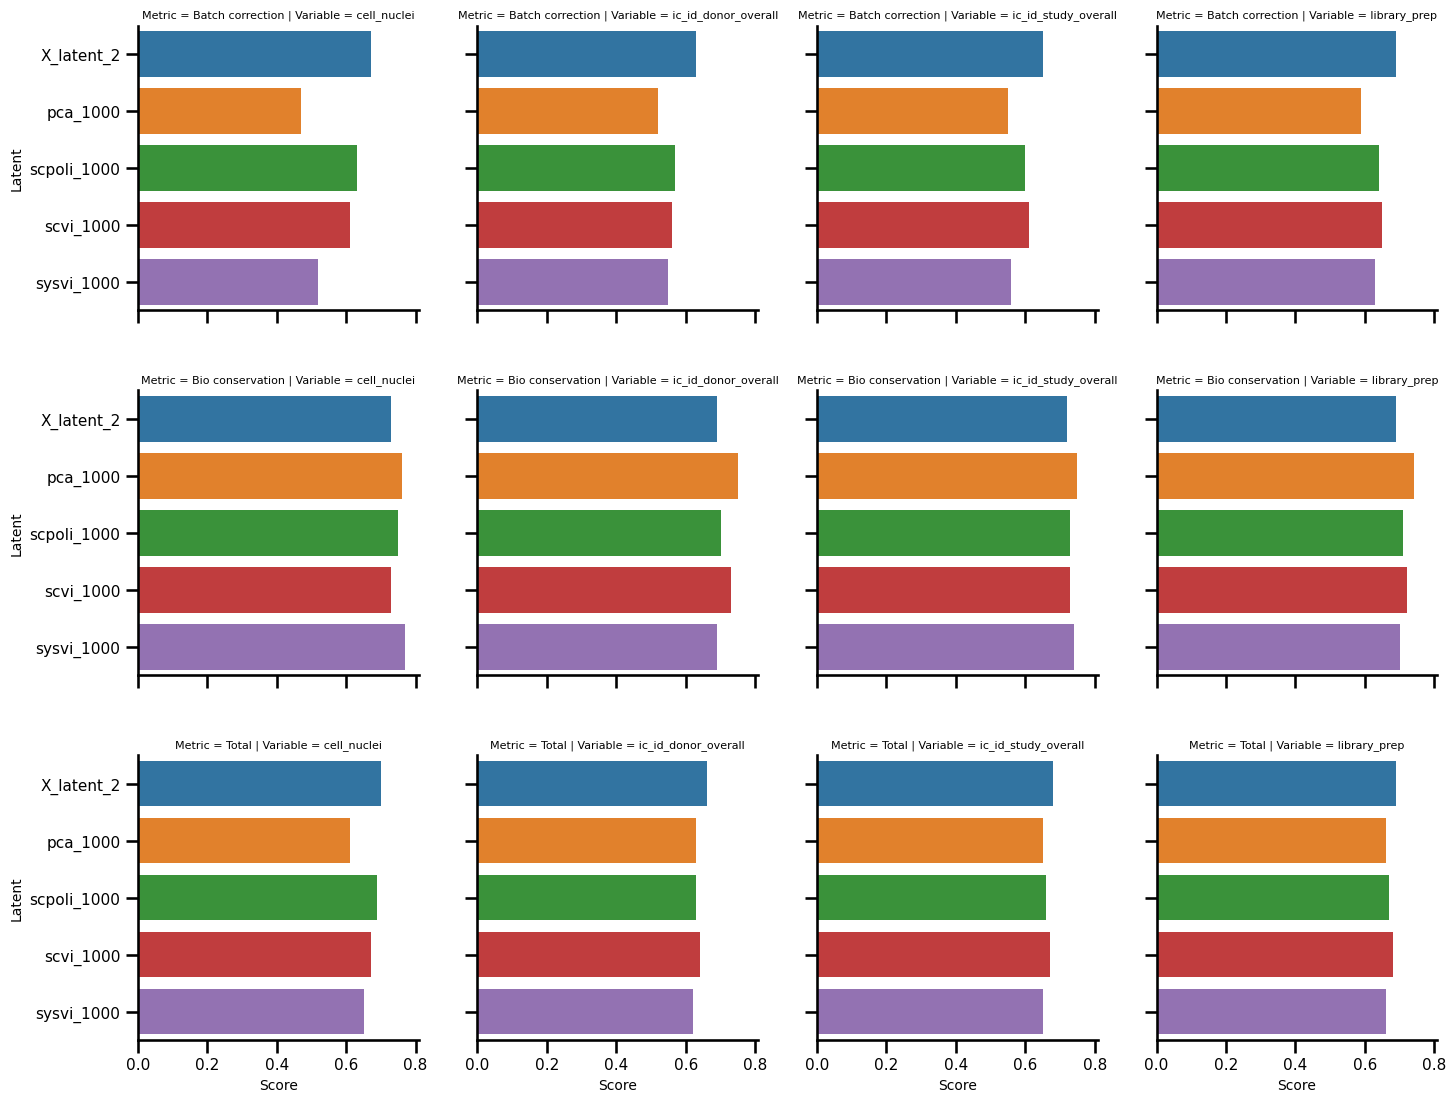

In [158]:
df_filt = df_res[
    (df_res["Metric"].isin(["Bio conservation", "Batch correction", "Total"]))
]


row_order = ["pca_1000", "X_latent_2", "scpoli_1000", "scvi_1000", "sysvi_1000"]

ax = sns.catplot(
    data=df_filt,
    x="Score",
    y="Latent",
    col="Variable",
    row="Metric",
    hue="Latent",
    kind="bar",
    height=4,
    label="Big",
)

for ax_i in ax.axes.flat:
    ax_i.set_title(ax_i.get_title(), fontsize=8)
    ax_i.set_xlabel(ax_i.get_xlabel(), fontsize=10)
    ax_i.set_ylabel(ax_i.get_ylabel(), fontsize=10)
    ax_i.tick_params(axis="both", which="major", labelsize=11)

# Adjust legend text size
if ax._legend:
    plt.setp(ax._legend.get_texts(), fontsize=11)
    ax._legend.set_title("Latent", prop={"size": 12})

plt.show()